# LeetCode #436: Find Right Interval

https://leetcode.com/problems/find-right-interval/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (nested loops)** | $O(n^2)$ | $O(1)$ |
| **Optimal: Binary Search on Sorted Starts ★** | $O(n \log n)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force (nested loops)
For each interval's end point, scan all other intervals to find the smallest start ≥ end. $O(n^2)$ — no leverage from sorting.

### Optimal: Binary Search on Sorted Starts ★
Sort interval start points (keeping their original indices) into an auxiliary array. For each interval's end point, binary search the sorted starts to find the leftmost start ≥ end in $O(\log n)$. Total: $O(n \log n)$ with $O(n)$ auxiliary space for the sorted starts.

**Constraints:**
* 1 <= intervals.length <= 2 * 10^4
* intervals[i].length == 2
* -10^6 <= start_i <= end_i <= 10^6
* The start point of each interval is unique


## Solutions

### C#

In [ ]:
public int[] FindRightInterval(int[][] intervals) {
    int n = intervals.Length;
    // Sort starts with their original indices for binary search lookup
    var starts = intervals.Select((iv, i) => (iv[0], i))
                          .OrderBy(x => x.Item1).ToArray();
    int[] result = new int[n];
    for (int i = 0; i < n; i++) {
        int end = intervals[i][1];
        // Binary search for smallest start >= end
        int lo = 0, hi = n;
        while (lo < hi) {
            int mid = lo + (hi - lo) / 2;
            if (starts[mid].Item1 >= end) hi = mid;
            else lo = mid + 1;
        }
        result[i] = lo < n ? starts[lo].i : -1;
    }
    return result;
}


### Python

In [ ]:
import bisect

def findRightInterval(self, intervals: list[list[int]]) -> list[int]:
    n = len(intervals)
    # Sort starts with their original indices for binary search lookup
    starts = sorted((iv[0], i) for i, iv in enumerate(intervals))
    start_vals = [s[0] for s in starts]
    result = []
    for start, end in intervals:
        # Binary search for smallest start >= end
        pos = bisect.bisect_left(start_vals, end)
        result.append(starts[pos][1] if pos < n else -1)
    return result


### Go

In [ ]:
import "sort"

func findRightInterval(intervals [][]int) []int {
    n := len(intervals)
    type pair struct{ start, idx int }
    // Sort starts with their original indices for binary search lookup
    starts := make([]pair, n)
    for i, iv := range intervals {
        starts[i] = pair{iv[0], i}
    }
    sort.Slice(starts, func(i, j int) bool { return starts[i].start < starts[j].start })
    result := make([]int, n)
    for i, iv := range intervals {
        end := iv[1]
        // Binary search for smallest start >= end
        lo, hi := 0, n
        for lo < hi {
            mid := lo + (hi-lo)/2
            if starts[mid].start >= end { hi = mid } else { lo = mid + 1 }
        }
        if lo < n { result[i] = starts[lo].idx } else { result[i] = -1 }
    }
    return result
}


### Rust

In [ ]:
pub fn find_right_interval(intervals: Vec<Vec<i32>>) -> Vec<i32> {
    let n = intervals.len();
    // Sort starts with their original indices for binary search lookup
    let mut starts: Vec<(i32, usize)> = intervals.iter().enumerate()
        .map(|(i, iv)| (iv[0], i)).collect();
    starts.sort();
    intervals.iter().map(|iv| {
        let end = iv[1];
        // Binary search for smallest start >= end
        let pos = starts.partition_point(|&(s, _)| s < end);
        if pos < n { starts[pos].1 as i32 } else { -1 }
    }).collect()
}


## Example Scenarios

**1. Common Case**
**Input:** intervals = [[1,2],[2,3],[3,4]]
Sorted starts: [(1,0),(2,1),(3,2)]. For [1,2]: end=2 → find start≥2 → (2,1) → index 1. For [2,3]: end=3 → (3,2) → index 2. For [3,4]: end=4 → no start≥4 → -1. Result: [1,2,-1].

**2. Slightly Complex**
**Input:** intervals = [[3,4],[2,3],[1,2]]
Sorted starts: [(1,2),(2,1),(3,0)]. For [3,4]: end=4→ no≥4 → -1. For [2,3]: end=3→ (3,0) → 0. For [1,2]: end=2→ (2,1) → 1. Result: [-1,0,1].

**3. Edge Case: Time Factor**
**Input:** n=2×10^4 intervals, all ends larger than all starts
Every binary search returns lo=n → -1 for all. Sort: $O(n \log n)$. Each search: $O(\log n)$. Total: $O(n \log n) \approx 2 \times 10^4 \times 14 \approx 2.8 \times 10^5$ operations.

**4. Edge Case: Space Factor**
**Input:** intervals = [[1,1]]
Sorted starts: [(1,0)]. end=1 → bisect finds (1,0) → index 0. Result: [0]. Extra space: the `starts` array of size n=1 → $O(n)$ auxiliary.

**5. Almost-Impossible but Plausible**
**Input:** intervals = [[-10^6, 10^6]] (single interval spanning full range)
end=10^6. Sorted starts: [(-10^6,0)]. Binary search: -10^6 < 10^6 → lo=1=n → result=-1. The interval's end exceeds its own start (and every possible start in a valid input per constraints where start_i is unique and only one interval exists).


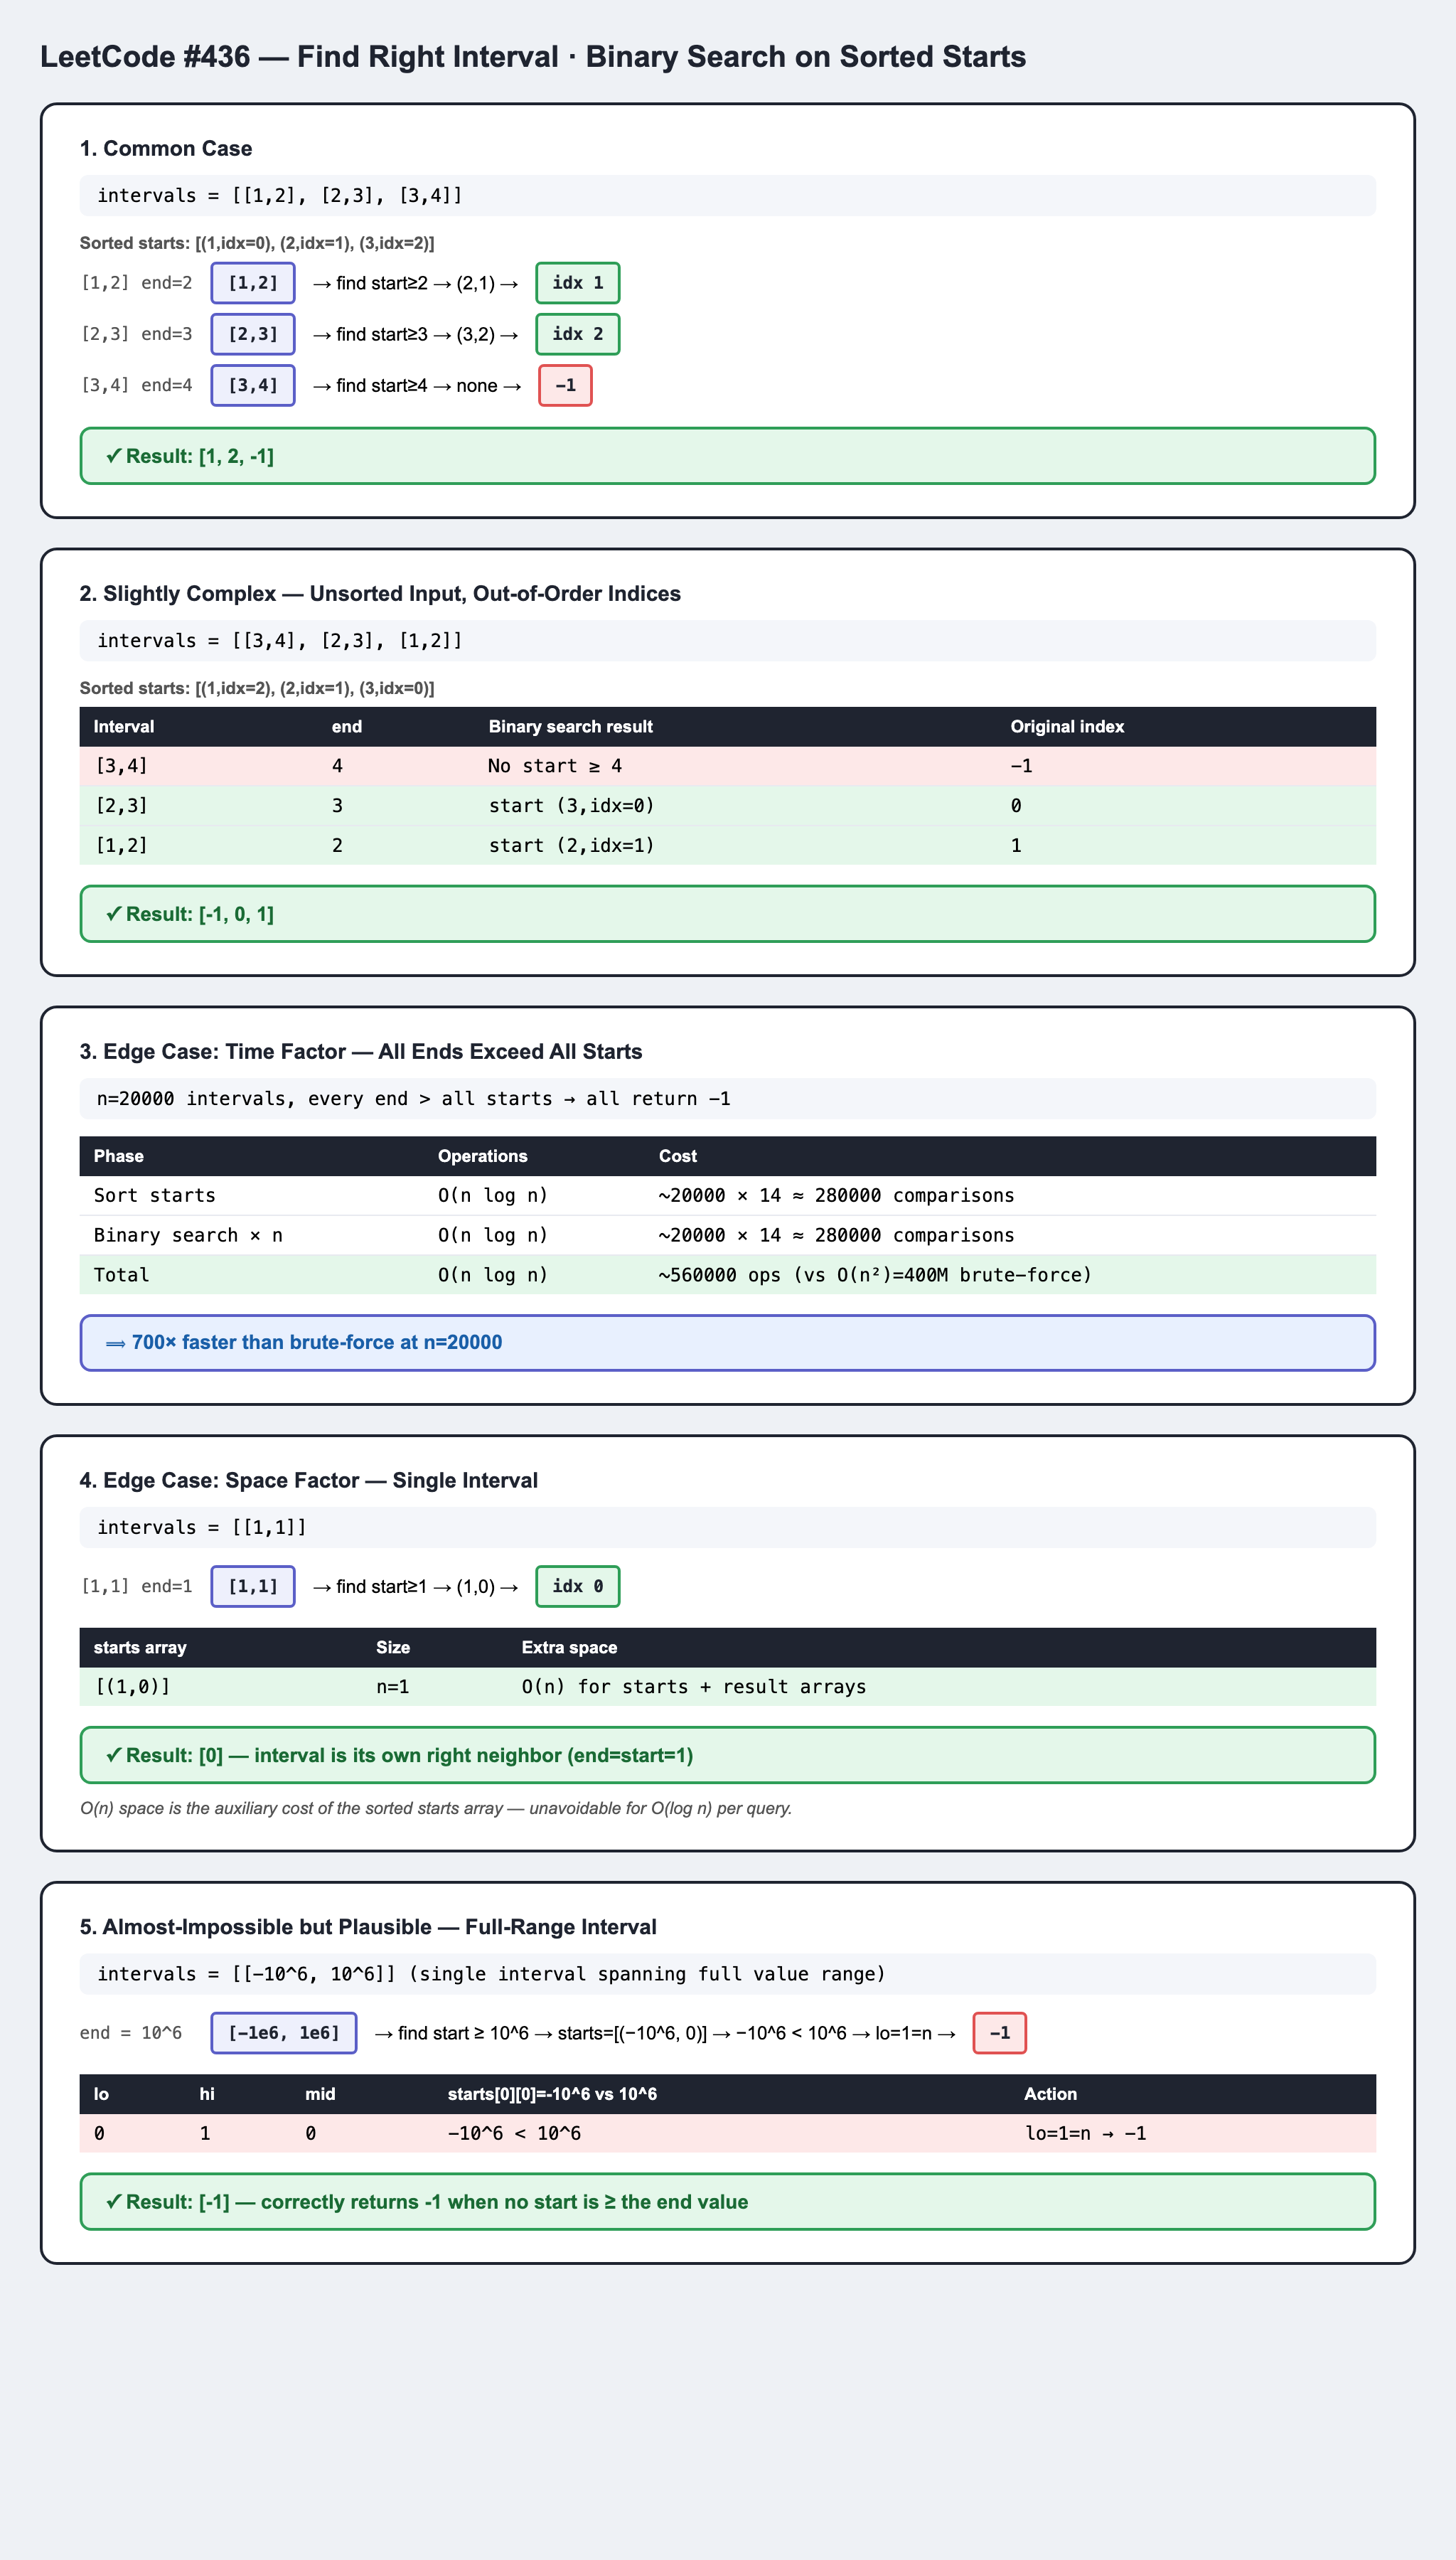